# Residential ground-water water-to-water heat pump
This example will walk you through a case study of a residential ground-water heat pump.

![Heatpump](assets/ground_water_heatpump.svg)


In [48]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from CoolProp.CoolProp import AbstractState

from refrigerationtoolbox.cycle.BasicHeatExchanger import BasicHeatExchanger
from refrigerationtoolbox.cycle.Cycle import Cycle
from refrigerationtoolbox.cycle.EffCompressor import EffCompressor
from refrigerationtoolbox.cycle.PlateHeatExchanger import PlateHeatExchanger
from refrigerationtoolbox.cycle.TransientCycle import TransientCycle
from refrigerationtoolbox.optimizer.PlateHeatExchangerCycleOptimizer import PlateHeatExchangerCycleOptimizer
from refrigerationtoolbox.plotter.CyclePlotter import CyclePlotter
from refrigerationtoolbox.plotter.TransientPlotter import TransientPlotter

In [49]:
def plot_ph_diagram(cycle: Cycle, title: str) -> None:
    """Helper function for plotting log p-h diagram."""
    fig, ax = plt.subplots(figsize=(6, 4.5))
    CyclePlotter().plot_ph(ax, cycle)
    ax.set_title(title)
    # Crop to the enthalpy band the cycle actually occupies, with 20 % margin
    h_lo = min(cycle.h3, cycle.h4) / 1e3
    h_hi = max(cycle.h1, cycle.h2) / 1e3
    margin = 0.2 * (h_hi - h_lo)
    ax.set_xlim(h_lo - margin * 3, h_hi + margin)
    fig.tight_layout()
    plt.show()

In [50]:
# Operating point of the heat pump
TE_START = 0 + 273.15  # [K] initial guess for the evaporation temperature
TC_START = 55 + 273.15  # [K] initial guess for the condensation temperature
SUPERHEAT = 5.0  # [K] superheat at the compressor inlet
SUBCOOLING = 5.0  # [K] subcooling at the condenser outlet

# Boundary conditions of the heat pump
T_GROUNDWATER = 10 + 273.15  # [K] ground water into the evaporator (the heat source)
T_SUPPLY = 35 + 273.15  # [K] heating water into the condenser (the heat sink)
M_FLOW_EVAP = 0.16  # [kg/s] ground water flow through the evaporator
M_FLOW_COND = 0.24  # [kg/s] heating water flow through the condenser
P_SEC = 1e5  # [Pa] pressure of both water circuits

# Refrigerant R290 (propane) against water on both secondary sides
fluid_ref = AbstractState("HEOS", "R290")
fluid_sec_evap = AbstractState("HEOS", "Water")
fluid_sec_cond = AbstractState("HEOS", "Water")

# Secondary-side boundary conditions, shared by every step below
boundary_conditions = dict(
    m_flow_sec_cond=M_FLOW_COND,
    p_sec_cond=P_SEC,
    T_sec_in_cond=T_SUPPLY,
    m_flow_sec_evap=M_FLOW_EVAP,
    p_sec_evap=P_SEC,
    T_sec_in_evap=T_GROUNDWATER,
)

----------------------------------------------------------------------
Step 1 - simple cycle (BasicHeatExchanger + EffCompressor)
----------------------------------------------------------------------
Cycle (refrigerant=n-Propane, Te=273.15, Tc=328.15, sh=5.0, sc=5.0)
   Q_heat: 4.42 kW, Q_ref: 3.19 kW, P_comp: 1.23 kW, COP_heat=3.58, COP_cool= 2.58, m_flow=0.01 kg/s
   State 1: T=278.15, P=474.46 kPa, h=583.57 kJ/kg, s=2.40 kJ/(kgK), rho=10.08 kg/m³
   State 2: T=350.32, P=1907.17 kPa, h=679.17 kJ/kg, s=2.49 kJ/(kgK), rho=36.84 kg/m³
   State 3: T=323.15, P=1907.17 kPa, h=336.56 kJ/kg, s=1.45 kJ/(kgK), rho=449.98 kg/m³
   State 4: T=273.15, P=474.46 kPa, h=336.56 kJ/kg, s=1.50 kJ/(kgK), rho=27.47 kg/m³


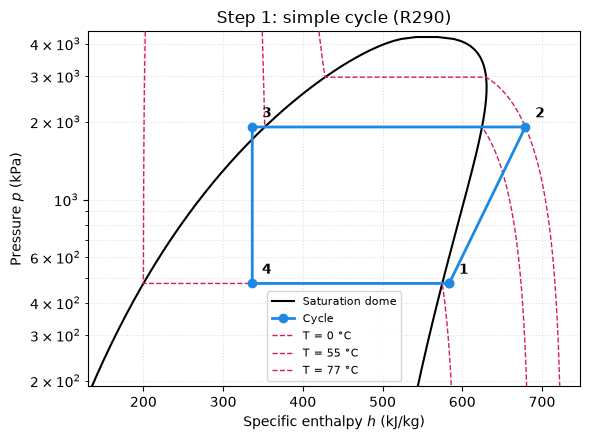

In [51]:
# Step 1 - simple cycle: ideal heat exchangers, efficiency-based compressor

# A scroll compressor of roughly 5 kW heating capacity
compressor = EffCompressor(fluid_ref, is_eff=0.7, vol_eff=0.8, N=6000 / 60, Vd=16e-6)

simple_cycle = Cycle(
    fluid_ref,
    Te=TE_START,
    Tc=TC_START,
    sh=SUPERHEAT,
    sc=SUBCOOLING,
    compressor=compressor,
    evaporator=BasicHeatExchanger(fluid_ref, fluid_sec_evap),
    condenser=BasicHeatExchanger(fluid_ref, fluid_sec_cond),
)
simple_cycle.calc(**boundary_conditions)

print("-" * 70)
print("Step 1 - simple cycle (BasicHeatExchanger + EffCompressor)")
print("-" * 70)
print(simple_cycle)

plot_ph_diagram(simple_cycle, "Step 1: simple cycle (R290)")

In [52]:
# Step 2 - swap in plate heat exchangers

# Geometry of plate heat exchanger, shared by evaporator and condenser
GEOM = {
    "plate_thickness_m": 0.0007,  # [m] plate wall thickness
    "chevron_angle_rad": np.deg2rad(60),  # [rad] chevron angle
    "plate_amplitude_m": 0.001,  # [m] corrugation amplitude
    "corrugation_pitch_m": 0.007,  # [m] corrugation pitch
    "Dp": 0.05,  # [m] port diameter
    "Lp": 0.5,  # [m] plate height
    "Bp": 0.25,  # [m] plate width
    "Ntmin": 4,  # smallest plate count considered when sizing
    "Ntmax": 150,  # largest plate count considered when sizing
    "Nt": 60,  # installed plate count
}
DP_MAX = 4e4  # [Pa] maximum allowed pressure drop per stream
DT_PINCH = 2.0  # [K] minimum allowed temperature difference between the streams

evaporator = PlateHeatExchanger(fluid_ref, fluid_sec_evap, GEOM, dp_ref_max=DP_MAX, dp_sec_max=DP_MAX, dT_pinch=DT_PINCH)
condenser = PlateHeatExchanger(fluid_ref, fluid_sec_cond, GEOM, dp_ref_max=DP_MAX, dp_sec_max=DP_MAX, dT_pinch=DT_PINCH)

plate_cycle = Cycle(
    fluid_ref,
    Te=TE_START,
    Tc=TC_START,
    sh=SUPERHEAT,
    sc=SUBCOOLING,
    compressor=compressor,
    evaporator=evaporator,
    condenser=condenser,
)
plate_cycle.calc(**boundary_conditions)

print("-" * 70)
print("Step 2 - same cycle with plate heat exchangers")
print("-" * 70)
print(evaporator)
print(condenser)

----------------------------------------------------------------------
Step 2 - same cycle with plate heat exchangers
----------------------------------------------------------------------
PlateHeatExchanger (evap, Q = 3.19 kW)
  Refrigerant [n-Propane] (m_flow = 0.01 kg/s p=474.46 kPa):
    Inlet : T=273.15 K, h=336.56 kJ/kg, s=1.50 kJ/kgK, d=27.47 kg/m³
    Outlet: T=278.15 K, h=583.57 kJ/kg, s=2.40 kJ/kgKd=10.08 kg/m³
  Secondary fluid [Water] (m_flow = 0.16 kg/s, p=100.00 kPa):
    Inlet : T=283.15 K, h=42.12 kJ/kg, s=0.15 kJ/kgK, d=999.70 kg/m³
    Outlet: T=287.90 K, h=62.05 kJ/kg, s=0.22 kJ/kgK, d=999.14 kg/m³
 Feasable = True, Nt = 60, dp_ref = 2.48 kPa, dp_sec = 0.12 kPa, self.dT_min = 5.00 K
PlateHeatExchanger (cond, Q = 4.42 kW)
  Refrigerant [n-Propane] (m_flow = 0.01 kg/s p=1907.17 kPa):
    Inlet : T=350.32 K, h=679.17 kJ/kg, s=2.49 kJ/kgK, d=36.84 kg/m³
    Outlet: T=323.15 K, h=336.56 kJ/kg, s=1.45 kJ/kgKd=449.98 kg/m³
  Secondary fluid [Water] (m_flow = 0.24 kg/s, p=10

----------------------------------------------------------------------
Step 3 - COP optimization
----------------------------------------------------------------------
PlateHeatExchangerCycleOptimizer (refrigerant=n-Propane, sh=5.0, sc=5.0)
   Te=276.15 K, Tc=320.58 K
   COP maximization: converged=True, COP=4.49, feasible=True
   Constraints (>= 0 is feasible, ~0 is active):
      condenser dT_min   +5.428e+00
      evaporator dT_min  -5.116e-13
      condenser dp_ref   +9.999e-01
      condenser dp_sec   +9.932e-01
      evaporator dp_ref  +9.416e-01
      evaporator dp_sec  +9.970e-01
      condenser A_phex   -9.332e-09
      evaporator A_phex  +7.311e-01
Cycle (refrigerant=n-Propane, Te=276.1499999998937, Tc=320.57844199526215, sh=5.0, sc=5.0)
   Q_heat: 4.94 kW, Q_ref: 3.84 kW, P_comp: 1.10 kW, COP_heat=4.49, COP_cool= 3.49, m_flow=0.01 kg/s
   State 1: T=281.15, P=519.43 kPa, h=587.00 kJ/kg, s=2.40 kJ/(kgK), rho=11.00 kg/m³
   State 2: T=340.08, P=1619.44 kPa, h=665.09 kJ/kg, s=2

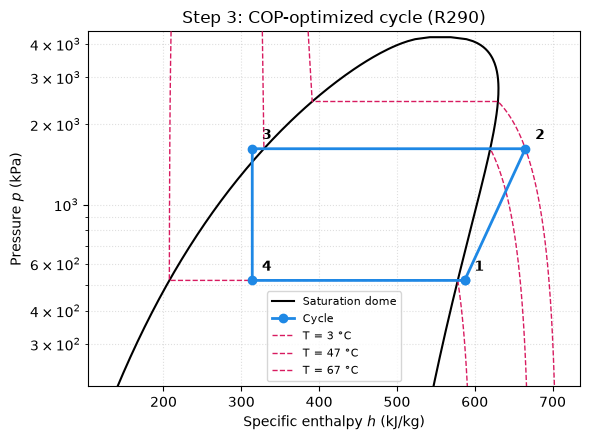

In [53]:
# Step 3 - maximize the heating COP over the evaporation/condensation temperature

optimizer = PlateHeatExchangerCycleOptimizer(
    fluid_ref,
    Te_start=TE_START,
    Tc_start=TC_START,
    sh=SUPERHEAT,
    sc=SUBCOOLING,
    compressor=compressor,
    evaporator=evaporator,
    condenser=condenser,
)
optimal_cycle = optimizer.optimize_cop(**boundary_conditions)

print("-" * 70)
print("Step 3 - COP optimization")
print("-" * 70)
print(optimizer)
print(f"\nCOP improved from {simple_cycle.COP_heat:.2f} to {optimal_cycle.COP_heat:.2f}")

plot_ph_diagram(optimal_cycle, "Step 3: COP-optimized cycle (R290)")


In [54]:
# Step 4 - minimum plate count at the optimum

# The optimizer drives the cycle onto a constraint, so the evaporator pinch sits
# exactly on its 2 K limit. Sizing is therefore done with 0.01 K of numerical
# slack, on fresh exchangers, so the optimized machine above stays untouched.
print("-" * 70)
print("Step 4 - minimum number of plates at the optimum")
print("-" * 70)

for name, sized in (("Evaporator", evaporator), ("Condenser", condenser)):
    candidate = PlateHeatExchanger(fluid_ref, sized.fluid_sec, GEOM, dp_ref_max=DP_MAX, dp_sec_max=DP_MAX, dT_pinch=DT_PINCH - 0.01)
    candidate.determine_min_n_plates(
        U0=2500,  # [W/m2K] first guess for the overall heat transfer coefficient
        m_flow_ref=sized.m_flow_ref,
        m_flow_sec=sized.m_flow_sec,
        h_ref_in=sized.h_ref_in,
        h_ref_out=sized.h_ref_out,
        p_ref=sized.p_ref,
        p_sec=sized.p_sec,
        T_sec_in=sized.T_sec_in,
    )
    print(
        f"{name:<11} {GEOM['Nt']:>3} plates installed -> {candidate.Nt:>3} plates needed "
        f"(feasible={candidate.feas}, dT_min={candidate.dT_min:.2f} K, "
        f"dp_ref={candidate.dp_ref / 1e3:.1f} kPa, dp_sec={candidate.dp_sec / 1e3:.1f} kPa)"
    )

----------------------------------------------------------------------
Step 4 - minimum number of plates at the optimum
----------------------------------------------------------------------
Evaporator   60 plates installed ->   4 plates needed (feasible=True, dT_min=2.00 K, dp_ref=7.8 kPa, dp_sec=23.7 kPa)
Condenser    60 plates installed ->  61 plates needed (feasible=True, dT_min=7.43 K, dp_ref=0.0 kPa, dp_sec=0.3 kPa)


----------------------------------------------------------------------
Step 5 - COP from 15 to 25 degC supply temperature
----------------------------------------------------------------------
  T_supply   COP_heat     Q_heat       Te       Tc  feasible
     25.0C       5.75     5.12kW     3.0C    37.9C      True
     25.5C       5.67     5.11kW     3.0C    38.4C      True
     26.0C       5.60     5.10kW     3.0C    38.9C      True
     26.5C       5.52     5.09kW     3.0C    39.3C      True
     27.0C       5.45     5.08kW     3.0C    39.8C      True
     27.5C       5.38     5.08kW     3.0C    40.3C      True
     28.0C       5.31     5.07kW     3.0C    40.8C      True
     28.5C       5.24     5.06kW     3.0C    41.3C      True
     29.0C       5.17     5.05kW     3.0C    41.7C      True
     29.5C       5.11     5.04kW     3.0C    42.2C      True
     30.0C       5.05     5.03kW     3.0C    42.7C      True
     30.5C       4.99     5.03kW     3.0C    43.2C      True
     31.0C    

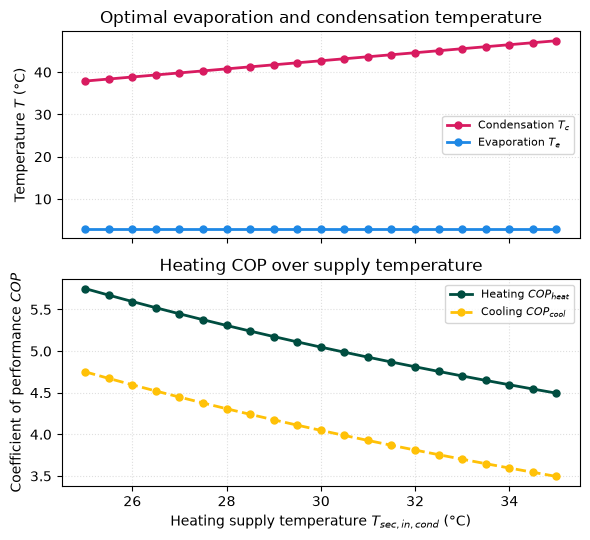

In [55]:
# Step 5 - COP over the heating supply temperature

# The supply temperature is varied in the sweep, so the plots are
# labelled in degC instead of seconds.
T_supply_sweep = np.linspace(25.0, 35.0, 21)

transient = TransientCycle(optimizer).calc(
    t=T_supply_sweep,
    m_flow_sec_cond=M_FLOW_COND,
    p_sec_cond=P_SEC,
    T_sec_in_cond=T_supply_sweep + 273.15,
    m_flow_sec_evap=M_FLOW_EVAP,
    p_sec_evap=P_SEC,
    T_sec_in_evap=T_GROUNDWATER,
)

print("-" * 70)
print("Step 5 - COP from 15 to 25 degC supply temperature")
print("-" * 70)
print(f"{'T_supply':>10} {'COP_heat':>10} {'Q_heat':>10} {'Te':>8} {'Tc':>8} {'feasible':>9}")
for i, T_supply in enumerate(T_supply_sweep):
    print(
        f"{T_supply:>9.1f}C {transient.COP_heat[i]:>10.2f} "
        f"{transient.Q_heat[i] / 1e3:>8.2f}kW {transient.Te[i] - 273.15:>7.1f}C "
        f"{transient.Tc[i] - 273.15:>7.1f}C {str(transient.feas[i]):>9}"
    )

fig, axes = plt.subplots(2, 1, figsize=(6, 5.5), sharex=True)
TransientPlotter().plot_transient(axes, transient, t_scale=1.0, t_label="Heating supply temperature $T_{sec,in,cond}$ (°C)")
axes[0].set_title("Optimal evaporation and condensation temperature")
axes[1].set_title("Heating COP over supply temperature")

fig.tight_layout()
plt.show()
